In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch as pt
from tqdm import tqdm
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from dataclasses import asdict
from pathlib import Path
import pandas as pd

from sklearn.model_selection import ParameterGrid

import scipy.stats.qmc as qm

from system_model import EAFModel, EAFParameters, step_eaf, TakeoutAnalysis

In [3]:
param_grid = {
    "O2_lance": [1.5, 2, 4, 6, 8],
    "P_arc": [30000, 35000, 40000, 55000, 75000],
    "O2_post": [0.5, 0.75, 1, 1.5, 2],
    "C_inj": [0.2, 0.25, 0.3, 0.5, 0.8],
    "FM_inj": [0.75, 1, 1.5, 2, 2.5],
    "DRI_add": [96, 110, 150],
}
sampler = qm.LatinHypercube(d=len(param_grid))

In [4]:
samples = sampler.random(n=10000) 
samples = qm.scale(
    samples,
    l_bounds=[min(v) for v in param_grid.values()],
    u_bounds=[max(v) for v in param_grid.values()],
)

In [5]:
samples_df = pd.DataFrame(
    samples, columns=list(param_grid.keys())
)
samples_df

,O2_lance,P_arc,O2_post,C_inj,FM_inj,DRI_add
0,3.080396,32545.058425,1.623196,0.525107,0.760856,126.073777
1,2.142689,52350.669720,1.918984,0.577567,1.640858,138.698964
2,5.648880,62064.497787,0.557153,0.482981,2.367452,120.122724
3,7.091979,52357.534283,1.601888,0.413724,1.469046,125.374379
4,3.681920,42726.840918,1.278745,0.639582,1.938611,133.596268
...,...,...,...,...,...,...
9995,5.846795,39732.104020,1.423295,0.347266,1.220064,133.996304
9996,4.010444,73068.931402,1.101700,0.617595,0.797627,121.525968
9997,6.750529,66082.960181,1.244318,0.569153,2.394655,108.088206
9998,2.351532,60869.819077,1.584677,0.793291,1.398243,119.829029


Running sample 0 with params: {'O2_lance': 3.0803957833784206, 'P_arc': 32545.058425337716, 'O2_post': 1.6231963512438172, 'C_inj': 0.5251065604353892, 'FM_inj': 0.7608560531568557, 'DRI_add': 126.07377655024632}


Time: 807.0s, T_lSc: 1872.7K:  32%|███▏      | 8071/24999 [00:50<01:45, 161.07it/s]


KeyboardInterrupt: 

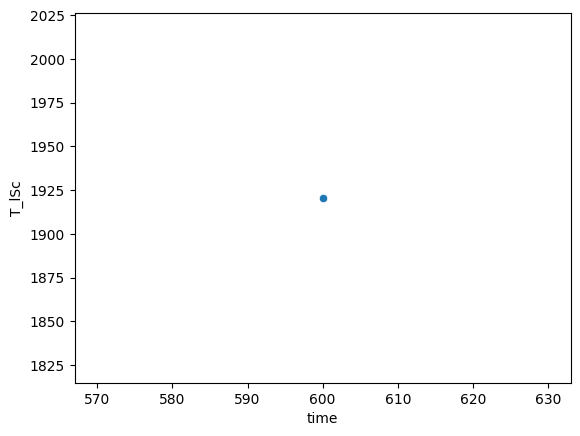

In [14]:
sampled_data = []
test_params = EAFParameters()
y_values = asdict(test_params)
y_values = [
    y_val
    for y_val in y_values.keys()
    if y_val.startswith("T_") or y_val.startswith("MX_")
]
sample_id = 0
results = []

params = samples_df.iloc[sample_id]
print(f"Running sample {sample_id} with params: {params.to_dict()}")
eaf_params = EAFParameters()
for k, v in params.items():
    setattr(eaf_params, k, v)
eaf_params.x_names = params.keys()

model = EAFModel(eaf_params)
last_takout = 0.0
gen = tqdm(range(int(model.p.secs // model.p.ts)))
for s in gen:
    
    step_eaf(model)

    time = s * model.p.ts
    gen.set_description(f"Time: {time:.1f}s, T_lSc: {model.p.T_lSc:.1f}K")

    if model.p.out > 0.0 and (time - last_takout) >= model.p.out:
        last_takout = time
        result = {
            "time": time,
            **params,
            **{y: getattr(model.p, y) for y in y_values},
        }
        for k, v in result.items():
            if isinstance(v, pt.Tensor):
                result[k] = v.item()
        results.append(result)
        results_df = pd.DataFrame(results)
        sns.scatterplot(data=results_df, x="time", y="T_lSc")
results_df

In [15]:
results_df

,time,O2_lance,P_arc,O2_post,C_inj,FM_inj,DRI_add,T_DRI,MX_Fe_DRI,MX_C_DRI,...,T_sSc,T_lSc,T_sSl,T_lSl,T_gas,T_wall,T_roof,T_air,T_melt,T_water
0,600.0,3.080396,32545.058425,1.623196,0.525107,0.760856,126.073777,559.32,0.88548,0.016336,...,766.954041,1920.552246,1045.692871,1843.246582,1771.797852,322.700165,335.106995,298,1809,298


In [ ]:
import seaborn as sns
sns.scatterplot(data=results_df, x="time", y=)

ValueError: Could not interpret value `MX_Slag` for `y`. An entry with this name does not appear in `data`.

In [ ]:
sampled_data_path = Path("./results")
samples_files= sampled_data_path.glob("eaf_simulation_*.csv")
samples_dfs = [pd.read_csv(f) for f in samples_files]
all_samples_df = pd.concat(samples_dfs, ignore_index=True)
all_samples_df

,O2_lance,P_arc,O2_post,C_inj,FM_inj,DRI_add,T_DRI,MX_Fe_DRI,MX_C_DRI,MX_SiO2_DRI,...,T_sSc,T_lSc,T_sSl,T_lSl,T_gas,T_wall,T_roof,T_air,T_melt,T_water
0,2.310802,51298.235248,0.742312,0.782470,0.994434,127.734178,559.32,0.88548,0.016336,0.057,...,768.909241,1732.527222,1051.411865,1707.515747,1702.092896,-85.931961,743.822876,298,1809,298
1,3.057981,53797.518474,1.646447,0.238414,1.631979,130.648588,559.32,0.88548,0.016336,0.057,...,760.958923,1830.675781,1059.778931,1808.278564,1777.012451,-158.581070,784.520325,298,1809,298
2,7.452928,58679.897172,1.002911,0.775335,2.169257,120.094611,559.32,0.88548,0.016336,0.057,...,776.279114,1991.975708,1051.045288,1956.341797,1876.290527,44.026752,612.683350,298,1809,298
3,3.543252,54241.694678,1.684579,0.306172,1.682857,102.587022,559.32,0.88548,0.016336,0.057,...,784.186279,1862.163696,1048.506470,1817.188721,1799.959351,311.059021,374.923798,298,1809,298
4,3.857847,49695.450405,1.143417,0.680465,2.205222,136.218204,559.32,0.88548,0.016336,0.057,...,863.720581,297.318512,569.680115,960.587524,1345.814697,-1068.847168,595.066162,298,1809,298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,7.425715,46019.724636,1.360181,0.620313,1.042240,141.598982,559.32,0.88548,0.016336,0.057,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,298,1809,298
9996,5.045465,51536.548396,0.791044,0.225469,1.497893,114.907563,559.32,0.88548,0.016336,0.057,...,778.731812,1883.592285,1050.488892,1844.578247,1810.175293,180.467407,472.203186,298,1809,298
9997,1.706731,62350.686244,1.555796,0.474092,1.554025,123.785523,559.32,0.88548,0.016336,0.057,...,773.811340,1735.463989,1049.005859,1705.151978,1707.434937,9.963335,676.560242,298,1809,298
9998,2.008160,71671.520181,0.614628,0.699702,2.134701,136.601973,559.32,0.88548,0.016336,0.057,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,298,1809,298


In [ ]:
all_samples_df=all_samples_df.dropna()
all_samples_df=all_samples_df[all_samples_df.apply(lambda row: all(np.isfinite(row)), axis=1)]

In [ ]:
all_samples_df.shape

(6080, 57)

In [ ]:
all_samples_df.to_csv( "eaf_simulation_data.csv", index=True)

In [ ]:

sampled_df = pd.DataFrame(sampled_data)
sampled_df.to_csv("eaf_simulation_data.csv", index=False)